# Reconstructing Hodgkin and Huxley (1952)

Hodgkin, A. L. & Huxley, A. F. (1952). A quantitative description of membrane
current and its application to conduction and excitation in nerve.
*Journal of Physiology* **117**, 500–544.
[doi:10.1113/jphysiol.1952.sp004764](https://doi.org/10.1113/jphysiol.1952.sp004764) ·
[page scans on PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC1392413/)

## What this notebook is

Every number, curve and prediction below comes from the constants printed in
the 1952 paper. Nothing is refitted, retuned, or quietly modernised. The point
is to walk the deduction the way Hodgkin and Huxley walked it: fit some
empirical functions to voltage-clamp measurements, assemble them into one
differential equation, and then find out what that equation knows that nobody
put into it.

That last step is the interesting one. The equations were fitted to a nerve
held at a fixed voltage. They were then asked about a nerve doing the thing
nerves actually do, and they answered correctly, including a conduction
velocity accurate to about 12%.

## What this notebook is not

It is not the paper. The 1952 text is still in copyright, and will be until
2047 in the United States and the end of 2082 in the United Kingdom. The
figures and the prose belong to The Physiological Society, and free access on
PMC is not a licence to redistribute.

So this is a reconstruction, not a reproduction. Equations are facts and are
set here in full. Short passages are quoted with page numbers, for criticism
and review. No scanned artwork appears, and no experimental data: where H&H
drew a curve through measured points, only the curve is drawn here. To see
their figures, follow the PMC link above, which puts the originals one click
away without anything being copied.

If you want the paper verbatim with commentary, that book exists and is good:
Raman & Ferster, *The Annotated Hodgkin and Huxley* (Princeton, 2021).

## A warning about signs

This trips up everyone who reads the paper after learning the modern
convention. H&H define

$$V = E - E_r$$

the membrane potential *minus* the resting potential, and they take
**depolarisation as negative**. Their figures then plot $-V$ upwards so the
spikes point the right way. Every constant in this notebook uses their
convention, because the alternative is to silently rewrite the paper.

So $V_{Na} = -115$ mV here, not $+55$ mV. If that looks wrong to you, it is
because it is upside down, not because it is incorrect.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from hh1952 import model as M
from hh1952 import figures as F

F.use_paper_style()

print(f"resting state:  m = {M.resting_state()[0]:.4f}, "
      f"h = {M.resting_state()[1]:.4f}, n = {M.resting_state()[2]:.4f}")

resting state:  m = 0.0529, h = 0.5961, n = 0.3177


---

# Part I. The membrane as a circuit

The paper opens by splitting the membrane current in two: some of it charges
the membrane capacity, the rest passes through it as ions.

$$I = C_M \frac{\mathrm{d}V}{\mathrm{d}t} + I_i \tag{1}$$

The ionic part divides again, into sodium, potassium, and everything else:

$$I_i = I_{Na} + I_K + I_l \tag{2}$$

$$I_{Na} = g_{Na}(V - V_{Na}) \qquad I_K = g_K(V - V_K) \qquad I_l = g_l(V - V_l)
\tag{3, 4, 5}$$

That is the whole of Part I, and it is worth pausing on how little it assumes.
Each ion gets a conductance and a battery, and the conductances are allowed to
vary. Nothing yet says *how* they vary. The figure below is what those five
equations look like as a circuit.

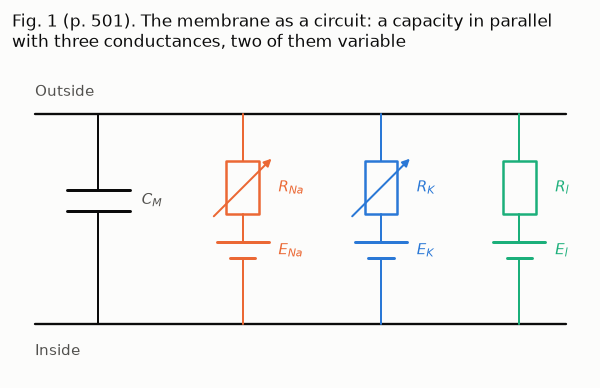

In [2]:
F.equivalent_circuit()
plt.show()

H&H were explicit that this picture was not a claim about mechanism. Earlier in
the paper they had considered a carrier molecule that ferries sodium across,
which was their own starting hypothesis, and dismissed it in one sentence
(p. 502):

> Here we can do little more than reject a suggestion which formed the
> original basis of our experiments.

The circuit is a bookkeeping device. It says the membrane has a capacity and
three parallel leaks, and it stays agnostic about what the leaks are made of.

---

# Part II. What the voltage clamp showed

Under a voltage clamp the experimenter fixes $V$ and watches the current. H&H
had already done this in the four companion papers. Part II is the work of
turning those records into functions.

## Potassium: a fourth power

The potassium conductance rises along an S-shaped curve and falls along a
simple exponential. A first-order process cannot do that; a first-order process
raised to a power can. H&H set $g_K = \bar{g}_K n^4$ and gave $n$ first-order
kinetics:

$$\frac{\mathrm{d}n}{\mathrm{d}t} = \alpha_n(1 - n) - \beta_n n \tag{7}$$

$$n_\infty = \frac{\alpha_n}{\alpha_n + \beta_n} \tag{9}$$

$$\tau_n = \frac{1}{\alpha_n + \beta_n} \tag{10}$$

The fourth power is the part everyone remembers, and it was chosen for the
shape of a curve, not for a mechanism. H&H say so themselves in the discussion
(p. 541):

> The agreement must not be taken as evidence that our equations are anything
> more than an empirical description of the time-course of the changes in
> permeability to sodium and potassium.

Fitting $\alpha_n$ and $\beta_n$ to the clamp records gave:

$$\alpha_n = \frac{0.01(V + 10)}{\exp\!\left(\frac{V+10}{10}\right) - 1} \tag{12}$$

$$\beta_n = 0.125 \exp\!\left(\frac{V}{80}\right) \tag{13}$$

## Sodium: two gates pulling opposite ways

Sodium was harder. Its conductance rises fast and then falls *while the
depolarisation is maintained*, so one variable cannot do it. H&H used two, an
activating $m$ that rises with depolarisation and an inactivating $h$ that
falls, with $g_{Na} = \bar{g}_{Na} m^3 h$:

$$\frac{\mathrm{d}m}{\mathrm{d}t} = \alpha_m(1 - m) - \beta_m m \tag{15}$$

$$\frac{\mathrm{d}h}{\mathrm{d}t} = \alpha_h(1 - h) - \beta_h h \tag{16}$$

$$\alpha_m = \frac{0.1(V + 25)}{\exp\!\left(\frac{V+25}{10}\right) - 1} \tag{20}$$

$$\beta_m = 4\exp\!\left(\frac{V}{18}\right) \tag{21}$$

$$\alpha_h = 0.07\exp\!\left(\frac{V}{20}\right) \tag{23}$$

$$\beta_h = \frac{1}{\exp\!\left(\frac{V+30}{10}\right) + 1} \tag{24}$$

Six functions, fitted by hand to families of clamp records. Everything that
follows in the paper is a consequence of these six and the circuit above.

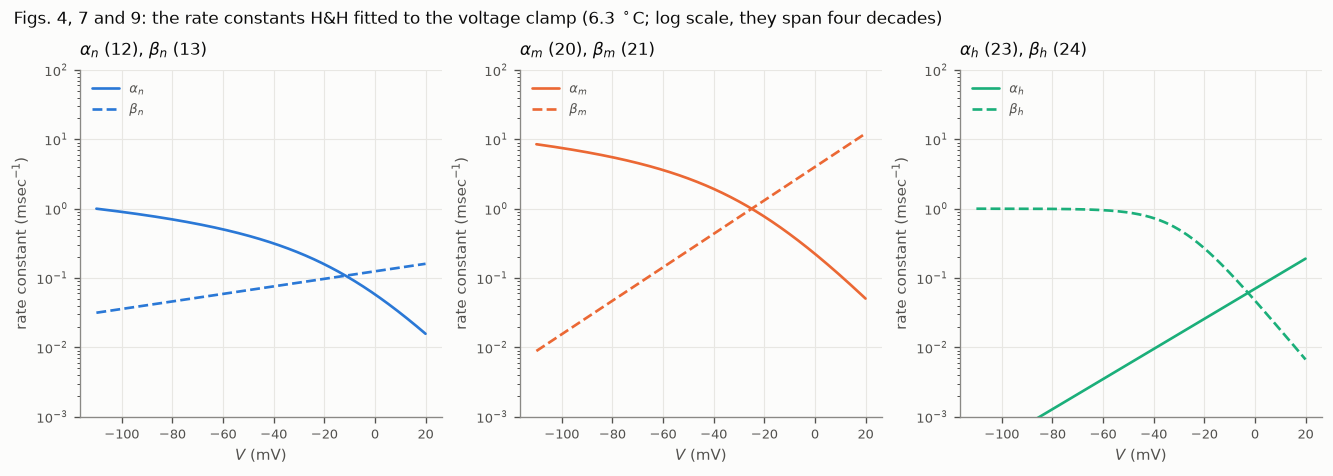

In [3]:
F.rate_constants()
plt.show()

Two things are worth noticing in those panels. $\alpha_m$ is an order of
magnitude larger than $\alpha_n$ over most of the range, which is why sodium
moves first. And $\alpha_h$ and $\beta_h$ cross well below the resting
potential, which is why $h$ sits at about 0.6 at rest rather than at 1: the
sodium system is already partly inactivated before anything happens.

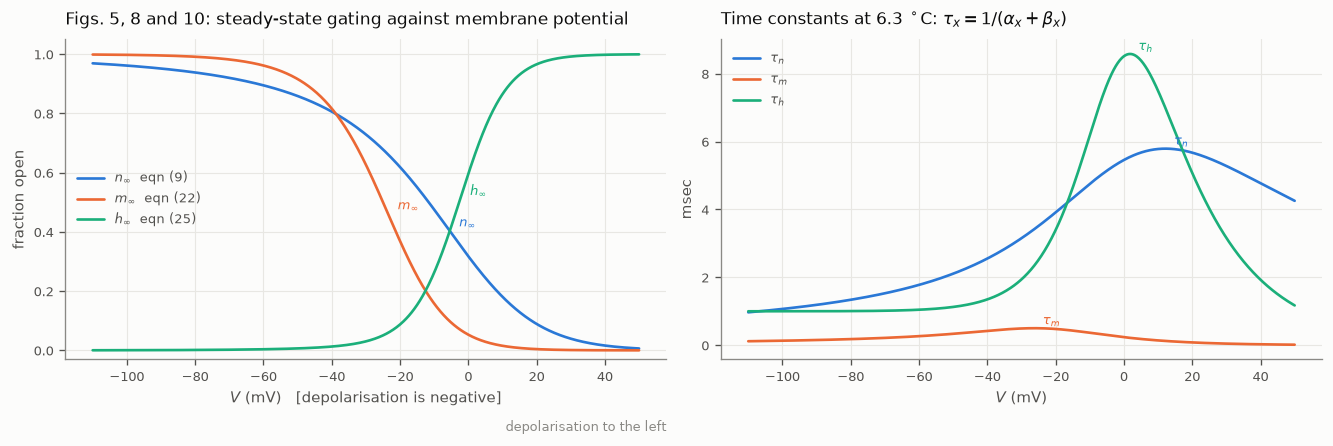

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6), constrained_layout=True)
F.steady_states(ax=axes[0])
F.time_constants(ax=axes[1])
plt.show()

The steady-state curves are the ones that carry the physiology. $m_\infty$ and
$h_\infty$ move in opposite directions and their curves overlap only in a
narrow window around rest. That overlap is the excitable region, and its
narrowness is why a nerve has a threshold.

The time constants say the rest of it: $\tau_m$ is small everywhere, so $m$
tracks the voltage almost instantly, while $\tau_h$ and $\tau_n$ peak near
rest at several milliseconds. Sodium turns on faster than it turns off, and
faster than potassium turns on. A spike is the gap between those rates.

## The conductance families

H&H fitted these families one curve at a time, each with its own parameters
from their Table 2, using closed-form solutions (eqns 11 and 19) that hold
only while $V$ is clamped. Below, the same families come out of the full $m$,
$h$, $n$ kinetics with no per-curve fitting at all. That is a slightly
stronger claim than the paper was able to make.

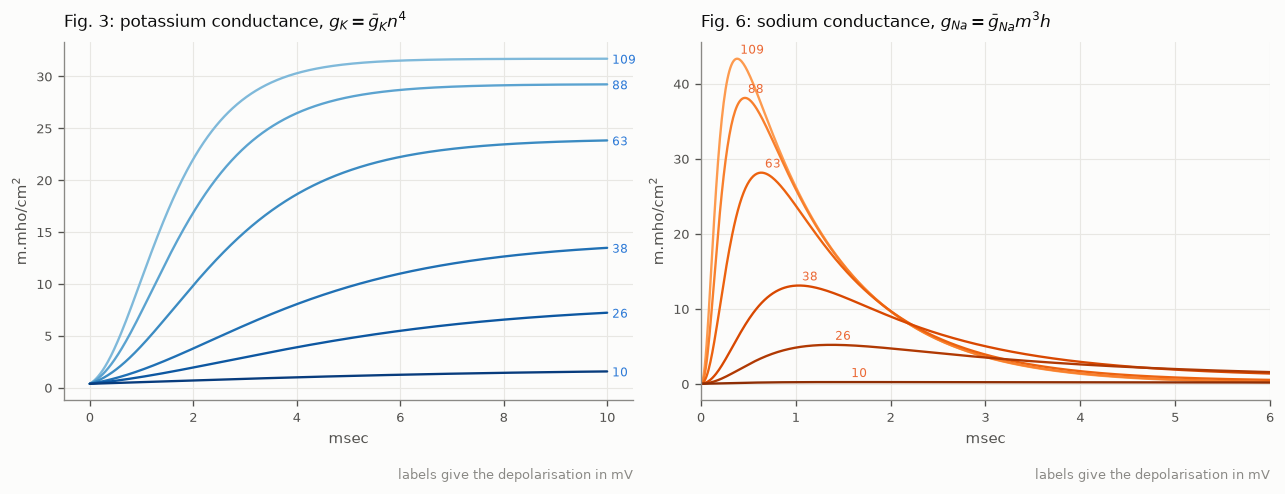

In [5]:
F.clamp_conductances()
plt.show()

---

# The model, complete

Collecting everything into one equation gives the paper's eqn (26), the line
that the rest of neuroscience was built on:

$$I = C_M \frac{\mathrm{d}V}{\mathrm{d}t}
    + \bar{g}_K n^4 (V - V_K)
    + \bar{g}_{Na} m^3 h (V - V_{Na})
    + \bar{g}_l (V - V_l) \tag{26}$$

with the constants, from p. 520:

| | value | |
|---|---|---|
| $C_M$ | 1.0 | µF/cm² |
| $\bar{g}_{Na}$ | 120 | m.mho/cm² |
| $\bar{g}_K$ | 36 | m.mho/cm² |
| $\bar{g}_l$ | 0.3 | m.mho/cm² |
| $V_{Na}$ | −115 | mV |
| $V_K$ | +12 | mV |
| $V_l$ | −10.613 | mV |

Temperature enters through a single factor, since H&H did not want to
recompute their rate tables (p. 523):

$$\phi = 3^{(T - 6.3)/10}$$

$V_l$ is the one fitted constant in the table. It has three decimal places
because it was chosen to make the total ionic current vanish exactly at rest.
Rounding cost them a little, and the residual is still there:

In [6]:
m0, h0, n0 = M.resting_state()
print(f"ionic current at V = 0:  {M.ionic_current(0.0, m0, h0, n0):+.3e} uA/cm^2")
print(f"                         ({abs(M.ionic_current(0.0, m0, h0, n0)) / 1e3:.1e} "
      f"of a typical peak current)")

ionic current at V = 0:  +4.224e-03 uA/cm^2
                         (4.2e-06 of a typical peak current)


---

# Part III. The deduction

Everything above was fitted. Everything below was predicted.

Set $I = 0$ in eqn (26), which is what happens to a space-clamped patch of
membrane after a brief shock, and integrate. H&H did this by hand, using
Hartree's method with a step size they adjusted as they went, "between about
0.01 msec at the beginning of a run or 0.02 msec during the rising phase of
the action potential, and 1 msec during the small oscillations which follow
the spike" (p. 523). One curve took days.

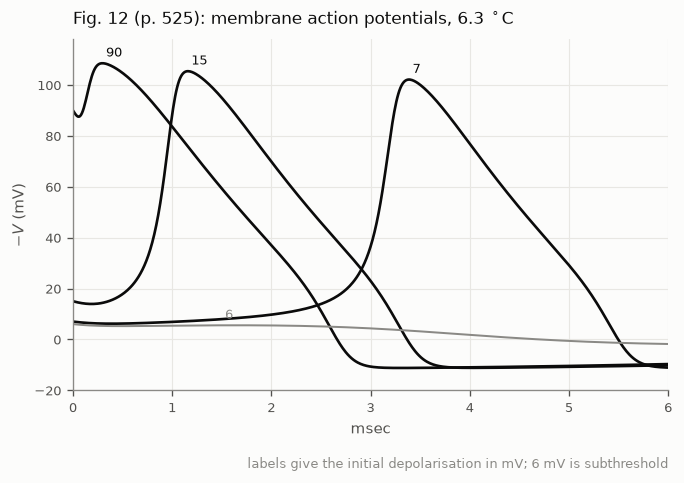

In [7]:
F.membrane_action_potentials()
plt.show()

This is the upper family of Fig. 12 on p. 525. The 90, 15 and 7 mV shocks all
produce a full spike of about 105 mV; the 6 mV shock does not. Compare against
the paper's own numbers:

| shock | this notebook | paper (Fig. 12) |
|---|---|---|
| 90 mV | peak at ≈0.30 ms | ≈0.3 ms |
| 15 mV | peak at ≈1.16 ms | ≈1.1 ms |
| 7 mV | peak at ≈3.39 ms | ≈3.4 ms |
| 6 mV | no spike | no spike |

Note the small dip on the leading edge of the 90 mV curve. That is in the
original too, and it is not an artefact: a shock large enough to overshoot
lets the potential fall back before the sodium current catches it.

In [8]:
for shock in (90, 15, 7, 6):
    tr = M.membrane_action_potential(shock, T=12.0)
    verdict = f"peak {tr.peak_depolarisation:6.2f} mV at {tr.time_to_peak:.2f} ms"
    print(f"{shock:>3} mV shock -> {verdict if tr.fired() else 'no spike':<32}")

 90 mV shock -> peak 108.54 mV at 0.30 ms       
 15 mV shock -> peak 105.41 mV at 1.16 ms       
  7 mV shock -> peak 102.13 mV at 3.39 ms       
  6 mV shock -> no spike                        


## What is happening underneath

The paper's Fig. 16 sets the spike beside the conductance that produces it.
This is the picture that made the model persuasive: the shape of the action
potential is not assumed anywhere, it falls out of two conductances with
different time courses.

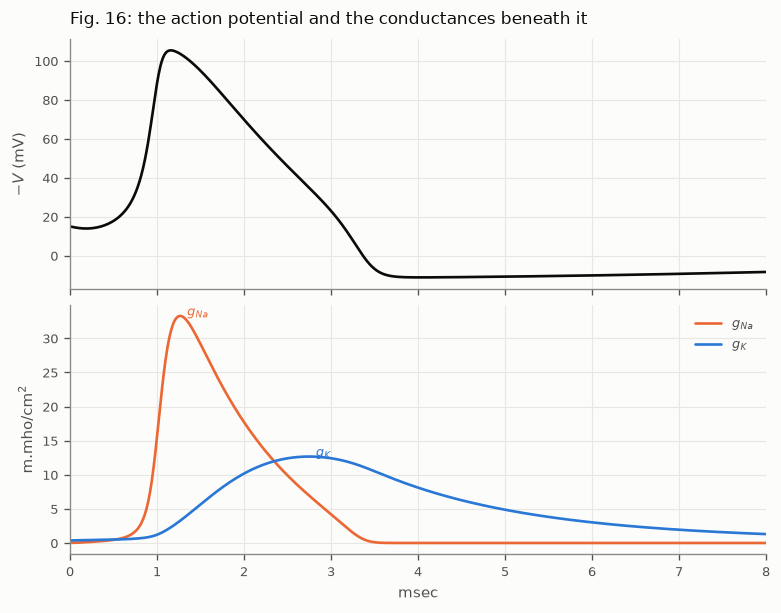

In [9]:
F.action_potential_with_conductances()
plt.show()

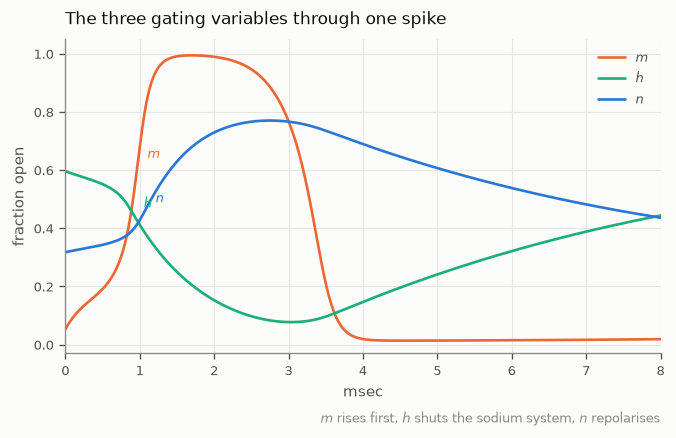

In [10]:
F.gating_variables()
plt.show()

Read left to right: $m$ rises almost vertically and sodium floods in; $h$
collapses a millisecond later and shuts the sodium system down; $n$ rises
slowly throughout and the potassium current drags the membrane back past its
resting potential. The undershoot at the end is $n$ taking its time to
close again, and it is the reason for the refractory period below.

---

# The propagated action potential

A real nerve does not depolarise all at once. Current spreads along the
axoplasm, which brings in a second derivative in distance:

$$I = \frac{a}{2R_2}\frac{\partial^2 V}{\partial x^2} \tag{28}$$

Substituting into eqn (26) gives a partial differential equation that H&H, in
1952, could not solve. Their way round it is the cleverest piece of
mathematics in the paper. If the wave propagates without changing shape, then
$V$ against time at one place has the same form as $V$ against distance at one
time, so

$$\frac{\partial^2 V}{\partial x^2} = \frac{1}{\theta^2}
\frac{\partial^2 V}{\partial t^2}$$

where $\theta$ is the conduction velocity. The partial differential equation
collapses to an ordinary one:

$$\frac{\mathrm{d}^2 V}{\mathrm{d}t^2} = K\left(C_M \frac{\mathrm{d}V}{\mathrm{d}t}
+ I_i\right), \qquad K = \frac{2R_2\theta^2 C_M}{a} \tag{30, 31}$$

The catch is that $\theta$ is what they wanted to find, and it appears in the
equation. So they guessed. From p. 522:

> It is necessary to guess a value of $\theta$, insert it in eqn. (30) and
> carry out the numerical solution starting from the resting state at the foot
> of the action potential. It is then found that $V$ goes off towards either
> $+\infty$ or $-\infty$, according as the guessed $\theta$ was too small or
> too large.

This is a shooting problem, and an unstable one. The correct value is a
separatrix: no finite $K$ gives a solution that stays bounded for ever. What
you converge on is the value whose trajectory follows the true action
potential longest before running away.

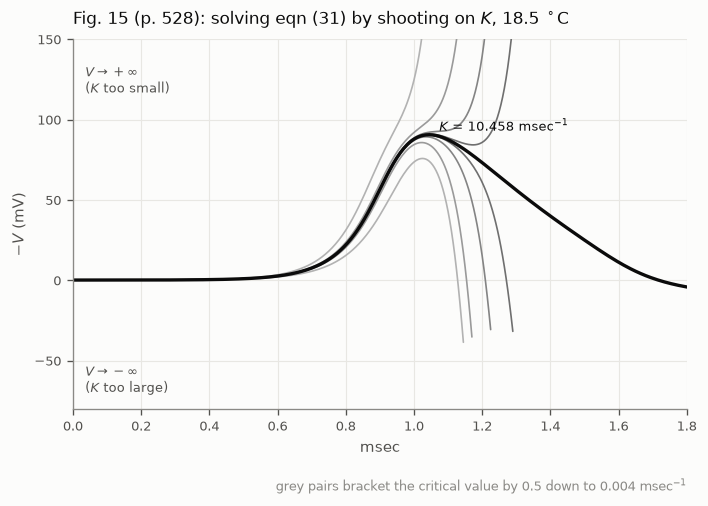

In [11]:
F.propagated_shooting()
plt.show()

Bisecting on their own divergence criterion, rather than guessing, gives:

In [12]:
K = M.find_K(temperature_C=18.5)
theta = M.conduction_velocity(K)

print(f"K      = {K:8.4f} msec^-1     paper: 10.47")
print(f"theta  = {theta:8.2f} m/sec       paper: 18.8 calculated, 21.2 measured")
print(f"error against the measured velocity: {100 * (theta - 21.2) / 21.2:+.1f} %")

K      =  10.4582 msec^-1     paper: 10.47
theta  =    18.75 m/sec       paper: 18.8 calculated, 21.2 measured
error against the measured velocity: -11.6 %


That is the number the whole argument rests on. The model was fitted to a
membrane clamped at fixed voltages, and it was then asked how fast a wave
would travel down an axon, which is a question about a completely different
experiment. It came back within 12% of the measured value.

H&H's arithmetic for axon 17, with radius $a = 0.0238$ cm and axoplasm
resistivity $R_2 = 35.4$ Ω cm (p. 528):

$$\theta = \left(\frac{K a}{2 R_2 C_M}\right)^{1/2}
= \left(\frac{10470 \times 0.0238}{2 \times 35.4 \times 10^{-6}}\right)^{1/2}
\text{cm/sec} = 18.8 \text{ m/sec}$$

---

# Three things nobody put in

The conduction velocity is the headline, but it is not the strongest part of
the case. These three are, because each is a named phenomenon from the
textbooks that appears in the solutions without having been fitted, mentioned,
or encoded anywhere in the six rate functions.

## Threshold

Nothing in eqn (26) contains a threshold. There is no `if` statement, no
switch, no critical value. The equation is smooth in $V$ throughout. And yet

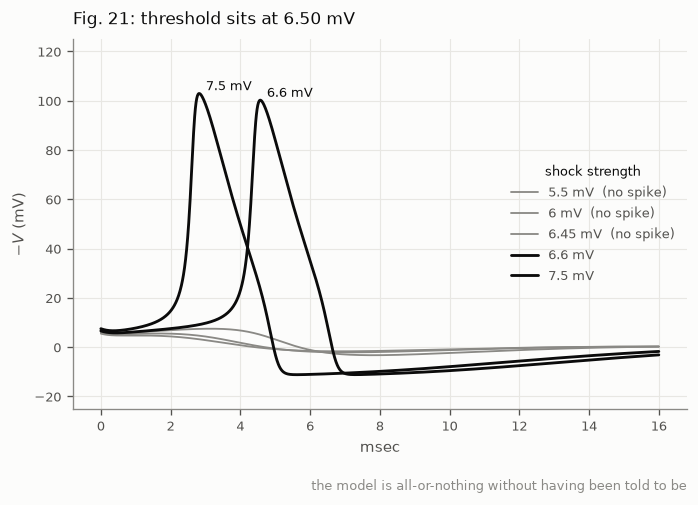

In [13]:
F.threshold()
plt.show()

In [14]:
thr = F.find_threshold()
print(f"threshold shock = {thr:.4f} mV at 6.3 degC")
print(f"a {thr - 0.01:.2f} mV shock decays; a {thr + 0.01:.2f} mV shock gives a full spike")

threshold shock = 6.5021 mV at 6.3 degC
a 6.49 mV shock decays; a 6.51 mV shock gives a full spike


H&H could only bracket this between 6 and 7 mV, because each curve on their
desk calculator cost days. Bisection puts it at 6.50 mV in about a second.
This is the one place in the notebook where having a computer buys a genuinely
new number rather than a faster old one.

The threshold exists because of the $m_\infty$/$h_\infty$ overlap seen
earlier: below it, $h$ closes faster than $m$ opens; above it, the other way
round. A smooth system produces an all-or-nothing response.

## The refractory period

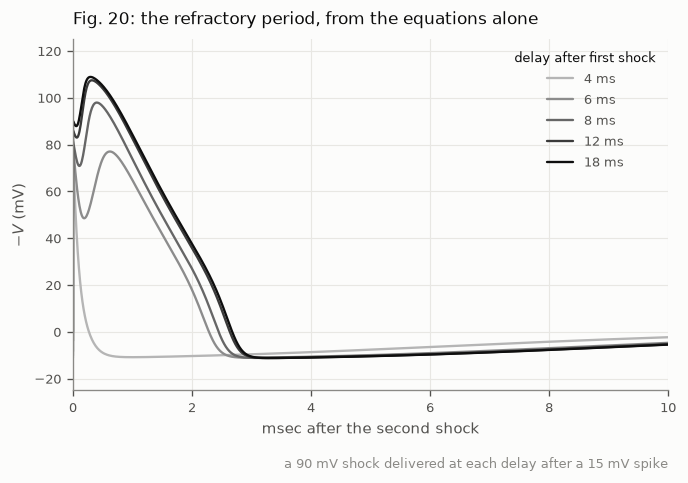

In [15]:
F.refractory_period()
plt.show()

A second shock delivered soon after the first produces a smaller spike, or
none. Wait long enough and the full response returns. Nothing in the equations
mentions refractoriness; it is $h$ and $n$ taking their time to return to rest.

## Anode break excitation

The strangest of the three, and the one that convinced people. Hold the
membrane *hyperpolarised*, then simply stop. No stimulus is applied. The nerve
fires anyway.

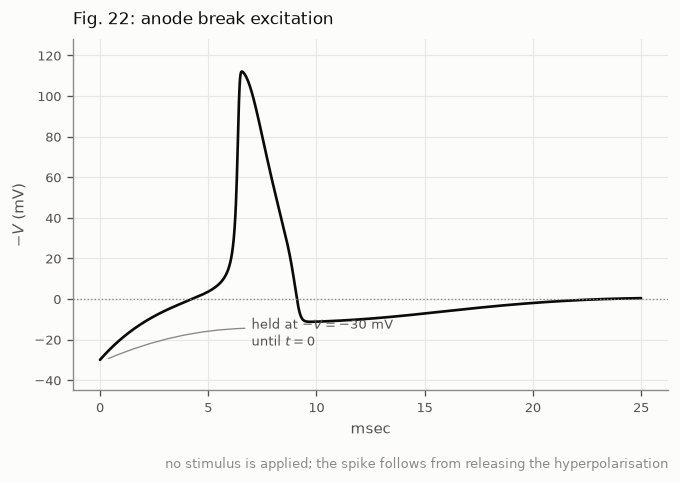

In [16]:
F.anode_break()
plt.show()

In [17]:
from hh1952.model import steady_state
print(f"h_inf at V = +30 mV (hyperpolarised): {steady_state('h', 30.0):.3f}")
print(f"h_inf at V =   0 mV (rest):           {steady_state('h',  0.0):.3f}")

h_inf at V = +30 mV (hyperpolarised): 0.992
h_inf at V =   0 mV (rest):           0.596


That is the whole explanation. Hyperpolarising removes the resting
inactivation, so $h$ climbs from 0.60 to 0.99. When the hyperpolarisation
ends, the membrane returns to a resting potential it has held a thousand times
before, but now with a sodium system that is fully available, and it fires.

Anode break excitation was a known laboratory curiosity in 1952, and an
awkward one. The model was never fitted to it. It simply falls out.

---

# Does the arithmetic hold up?

H&H were careful about their own numerics, and made a claim worth checking
(p. 523):

> It is difficult to estimate the degree to which the errors at successive
> steps accumulate, but we are confident that the overall errors are not large
> enough to be detected in the illustrations of this paper.

Their step was 0.01 to 0.02 msec on the rising phase. Forward Euler at that
step, against an adaptive stiff solver:

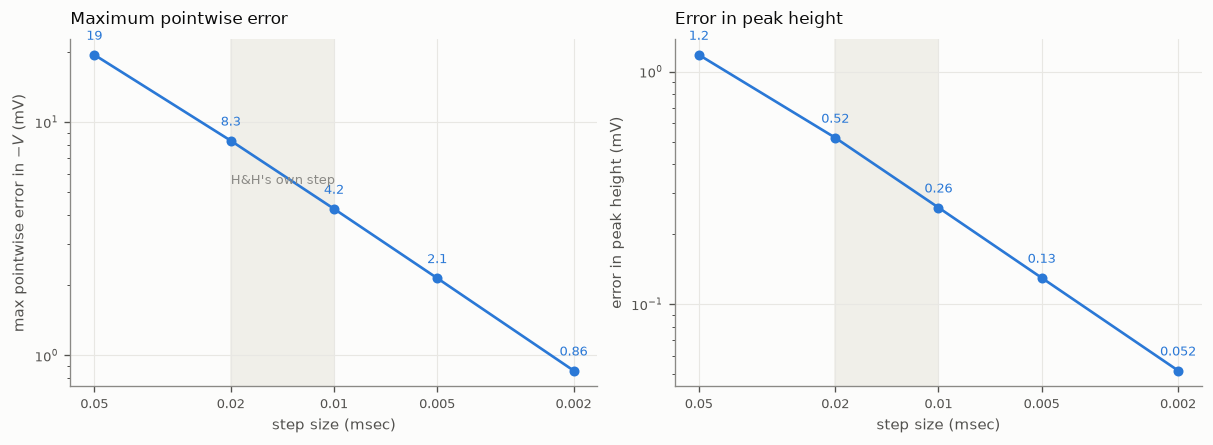

 step (ms)   max error  peak error
      0.05      19.42 mV      1.18 mV
      0.02       8.32 mV      0.52 mV
      0.01       4.25 mV      0.26 mV
     0.005       2.14 mV      0.13 mV
     0.002       0.86 mV      0.05 mV


In [18]:
axes, errors = F.integrator_comparison()
plt.show()

print(f"{'step (ms)':>10} {'max error':>11} {'peak error':>11}")
for dt in errors["pointwise"]:
    print(f"{dt:>10} {errors['pointwise'][dt]:>10.2f} mV "
          f"{errors['peak'][dt]:>9.2f} mV")

The two panels disagree, and the disagreement is the interesting part. At
H&H's step size the maximum pointwise error is 4 to 8 mV, which sounds bad.
The error in peak height is 0.26 to 0.52 mV, which is half a percent.

Both are correct. The rising phase of a spike is nearly vertical, so a shift
of a hundredth of a millisecond in *when* the upstroke happens registers as
several millivolts of difference in *what the voltage is* at a given instant.
Almost all of that 8 mV is timing, not amplitude. Their curves were the right
height and the right shape; they may have sat a few microseconds off.

Two further points are owed to them. Forward Euler is first-order and
Hartree's method is not, so the real error in their hand computation at a
given step was smaller than the figures above, which are an upper bound on it
rather than an estimate. And they adjusted the step as they went, using the
small values only where the solution was moving fast. Their claim stands.

It cuts the other way too. A modern solver is *more* accurate than the curves
printed in the paper, so a reconstruction has to decide what it is reproducing:
their results or their arithmetic. This notebook reproduces their results, and
keeps `method="euler"` available for anyone who wants the other thing.

---

# The scorecard

The reason this paper still gets cited in arguments about modelling is the
gap between the left column and the right.

**Fitted to voltage-clamp data**

- the forms $n^4$ and $m^3h$, chosen for curve shape
- six rate functions $\alpha_n, \beta_n, \alpha_m, \beta_m, \alpha_h, \beta_h$
- four conductance and capacity constants
- three equilibrium potentials, one of them ($V_l$) tuned to balance the rest

**Never fitted, and predicted anyway**

- the existence and shape of the action potential
- its amplitude, to within a few mV
- the conduction velocity, to 12%
- a sharp threshold in a smooth system
- the refractory period and its time course
- anode break excitation
- subthreshold oscillations and accommodation

A curve-fit reproduces what it was shown. This one answered questions it was
never asked, which is the difference between a model that describes and a model
that explains.

H&H saw the objection coming and closed it off. The worry about any model that
predicts well is that it was quietly tuned until it did, and they point out
that the tuning was not available to them (p. 541):

> Indeed any such adjustment would be extremely difficult, because in most
> cases it is impossible to tell in advance what effect a given change in one
> of the equations will have on the final solution.

That is the shooting problem again, turned into an epistemological argument.
When you cannot predict what a parameter change will do, you cannot fudge the
parameters, so agreement means something.

Their own summary of what had been established is narrower than the one the
textbooks give them, and better (p. 541):

> The point that we do consider to be established is that fairly simple
> permeability changes in response to alterations in membrane potential, of
> the kind deduced from the voltage clamp results, are a sufficient
> explanation of the wide range of phenomena that have been fitted by
> solutions of the equations.

Sufficient, not true. The $n^4$ turned out sixty years later to correspond to
four real voltage sensors in a real tetrameric channel, which is a happier
ending than they expected, and one they were careful not to claim.

---

# Sources and reuse

The paper: Hodgkin & Huxley (1952), *J. Physiol.* **117**, 500–544,
[doi:10.1113/jphysiol.1952.sp004764](https://doi.org/10.1113/jphysiol.1952.sp004764).
Page scans are free to read at
[PMC1392413](https://pmc.ncbi.nlm.nih.gov/articles/PMC1392413/), courtesy of
The Physiological Society. Free to read is not free to redistribute: the work
is under copyright until 2047 (US) and the end of 2082 (UK), and PMC's own
[copyright notice](https://pmc.ncbi.nlm.nih.gov/about/copyright/) is explicit
that free access does not imply reuse rights.

The four companion papers, all in *J. Physiol.* 116 (1952), carry the
measurements this one draws on:

- Hodgkin, Huxley & Katz, 116, 424–448, on current-voltage relations
- Hodgkin & Huxley, 116, 449–472, on currents carried by sodium and potassium
- Hodgkin & Huxley, 116, 473–496, on the components of membrane conductance
- Hodgkin & Huxley, 116, 497–506, on the dual effect of potential on $g_{Na}$

This notebook's own code and prose are MIT licensed. Nothing in it is
reproduced from the paper except short quotations, cited by page, and the
equations, which are facts and not anyone's property.